# 95 - Overlap セグメント戦略の評価

ArcFace 顔埋め込み (512次元, 約75K faces) に対して、**Overlap バンド分割**の効果を検証する。

通常のバンド分割（非重複）では、ビット列を連続ブロックに分割するが、
Overlap 戦略では stride < width として重複するバンドを構成し、
候補のヒット確率を調整する。

## パラメータ空間
- **Overlap 設定**: (width=8, stride=4), (width=12, stride=4), (width=16, stride=8)
- **ビット数**: 64, 96, 128
- **min_matches**: 1, 2, 3（バンド一致の最小要求数）

## 評価指標
- **候補削減率**: candidates / total（小さいほど高速）
- **Recall@10**: ブルートフォースの Top-10 と比較した再現率

## 入力
- `data/images.duckdb` (`face_detections` テーブル, model_name='buffalo_l')

## 出力
- パラメータ別の削減率 × Recall@10 トレードオフ分析
- 75K 規模での有効性分析
- 100K / 500K / 1M へのスケール外挿

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from image_vector_poc.search.lsh.itq import ITQLSH

DB_PATH = Path("../data/images.duckdb")
MODEL_DIR = Path("../data/itq_models")
TOP_K = 10

conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

rows = conn.execute("""
    SELECT f.face_id, f.embedding
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()
conn.close()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / norms

N_TOTAL = len(embeddings)
print(f"Loaded {N_TOTAL:,} faces")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 75,162 faces


In [2]:
# ITQ モデル読み込みとハッシュ生成
BIT_COUNTS = [64, 96, 128]
all_hashes = {}

for n_bits in BIT_COUNTS:
    model_path = MODEL_DIR / f"itq_arcface_{n_bits}bit.pkl"
    if model_path.exists():
        itq = ITQLSH.load(str(model_path))
        all_hashes[n_bits] = itq.transform(embeddings)
        print(f"  {n_bits}bit: hash shape {all_hashes[n_bits].shape}")
    else:
        print(f"  {n_bits}bit: model not found, training...")
        itq = ITQLSH(n_bits=n_bits, seed=42)
        itq.fit(embeddings)
        all_hashes[n_bits] = itq.transform(embeddings)
        itq.save(str(model_path))

# Overlap バンドインデックス構築関数
def build_overlap_band_index(hashes, width, stride):
    n_bits = hashes.shape[1]
    n_bands = (n_bits - width) // stride + 1
    band_indices = {}
    for b in range(n_bands):
        start = b * stride
        band_bits = hashes[:, start:start + width]
        band_dict = {}
        for i in range(len(band_bits)):
            key = 0
            for bit in band_bits[i]:
                key = (key << 1) | int(bit)
            band_dict.setdefault(key, []).append(i)
        band_indices[b] = band_dict
    return band_indices, n_bands

def overlap_band_filter(query_hash, band_indices, width, stride, n_bands, min_matches=1):
    candidate_counts = Counter()
    for b in range(n_bands):
        start = b * stride
        q_bits = query_hash[start:start + width]
        key = 0
        for bit in q_bits:
            key = (key << 1) | int(bit)
        if key in band_indices[b]:
            for idx in band_indices[b][key]:
                candidate_counts[idx] += 1
    return np.array([idx for idx, cnt in candidate_counts.items() if cnt >= min_matches])

print("Helper functions defined")

  64bit: hash shape (75162, 64)


  96bit: hash shape (75162, 96)


  128bit: hash shape (75162, 128)
Helper functions defined


## 1. バンドインデックスの構築と候補削減率

In [3]:
OVERLAP_CONFIGS = [(8, 4), (12, 4), (16, 8)]
MIN_MATCHES_LIST = [1, 2, 3]
N_QUERIES = 50
rng = np.random.default_rng(42)
query_idx = rng.choice(N_TOTAL, N_QUERIES, replace=False)

# Ground truth
ground_truth = {}
for qi in query_idx:
    sims = embeddings @ embeddings[qi]
    sims[qi] = -1
    ground_truth[qi] = np.argsort(-sims)[:TOP_K]

# 全設定でバンドインデックス構築 + 評価
results = []

for n_bits in BIT_COUNTS:
    hashes = all_hashes[n_bits]
    for width, stride in OVERLAP_CONFIGS:
        if width > n_bits:
            continue
        
        band_idx, n_bands = build_overlap_band_index(hashes, width, stride)
        
        for min_matches in MIN_MATCHES_LIST:
            candidate_sizes = []
            recalls = []
            
            for qi in query_idx:
                candidates = overlap_band_filter(hashes[qi], band_idx, width, stride, n_bands, min_matches)
                candidate_sizes.append(len(candidates))
                
                if len(candidates) > 0:
                    gt_set = set(ground_truth[qi])
                    recall = len(set(candidates) & gt_set) / TOP_K
                else:
                    recall = 0.0
                recalls.append(recall)
            
            mean_cand = np.mean(candidate_sizes)
            mean_recall = np.mean(recalls)
            reduction = mean_cand / N_TOTAL
            
            results.append({
                "bits": n_bits, "width": width, "stride": stride,
                "n_bands": n_bands, "min_matches": min_matches,
                "mean_candidates": mean_cand,
                "reduction_rate": reduction,
                "recall@10": mean_recall,
            })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format="%.4f"))

 bits  width  stride  n_bands  min_matches  mean_candidates  reduction_rate  recall@10
   64      8       4       15            1        4517.1800          0.0601     0.6840
   64      8       4       15            2         487.4600          0.0065     0.4260
   64      8       4       15            3          92.0000          0.0012     0.2880
   64     12       4       14            1         371.9800          0.0049     0.3460
   64     12       4       14            2          57.8200          0.0008     0.1860
   64     12       4       14            3          14.5600          0.0002     0.1140
   64     16       8        7            1          41.0800          0.0005     0.1460
   64     16       8        7            2           4.1600          0.0001     0.0320
   64     16       8        7            3           1.1800          0.0000     0.0120
   96      8       4       23            1        6454.6200          0.0859     0.7180
   96      8       4       23            2 

## 2. Recall@10 vs 削減率のトレードオフ

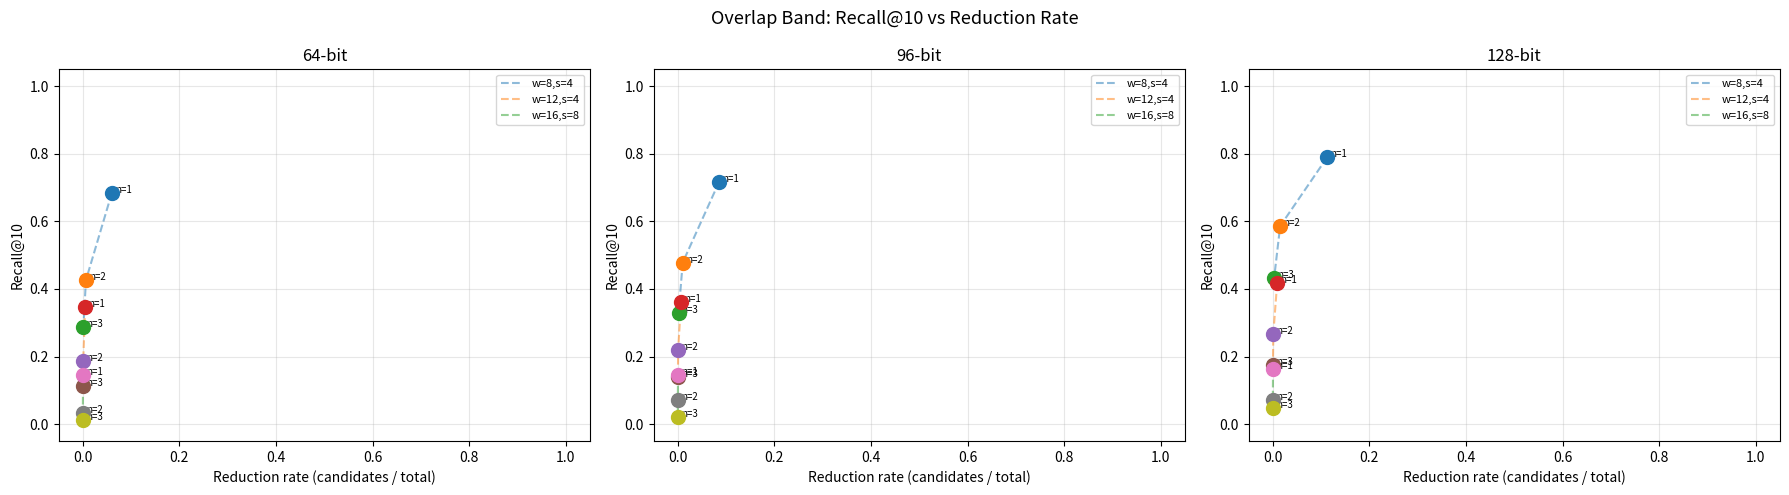


Recall@10 >= 0.8 を満たす構成なし


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, n_bits in enumerate(BIT_COUNTS):
    ax = axes[idx]
    subset = results_df[results_df["bits"] == n_bits]
    
    for (w, s), grp in subset.groupby(["width", "stride"]):
        for _, row in grp.iterrows():
            ax.scatter(row["reduction_rate"], row["recall@10"],
                      s=100, zorder=5)
            ax.annotate(f"m={int(row['min_matches'])}",
                       (row["reduction_rate"], row["recall@10"]),
                       fontsize=7, ha="left")
        ax.plot(grp["reduction_rate"], grp["recall@10"], "--", alpha=0.5,
                label=f"w={w},s={s}")
    
    ax.set_xlabel("Reduction rate (candidates / total)")
    ax.set_ylabel("Recall@10")
    ax.set_title(f"{n_bits}-bit")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle("Overlap Band: Recall@10 vs Reduction Rate", fontsize=13)
plt.tight_layout()
plt.show()

# ベスト構成（Recall≥0.8 で最小削減率）
good = results_df[results_df["recall@10"] >= 0.8].sort_values("reduction_rate")
if len(good) > 0:
    print("\nRecall@10 >= 0.8 の構成（削減率順）:")
    print(good[["bits", "width", "stride", "min_matches", "reduction_rate", "recall@10"]].head(10).to_string(index=False, float_format="%.4f"))
else:
    print("\nRecall@10 >= 0.8 を満たす構成なし")

## 3. スケール外挿

75K 規模の候補数からバンド衝突確率を推定し、100K / 500K / 1M でのスケール外挿を行う。

In [5]:
# 候補削減率はデータサイズに依存しにくい（衝突確率は一定）
# → 候補数はデータサイズに比例すると仮定して外挿
scale_factors = {"75K (actual)": 1.0, "100K": 100_000/N_TOTAL, "500K": 500_000/N_TOTAL, "1M": 1_000_000/N_TOTAL}

# ベスト構成をいくつかピックアップ
best_configs = results_df.nlargest(5, "recall@10").head(5)

print("スケール外挿: 推定候補数")
print(f"{'Config':>30} | {'75K':>8} | {'100K':>8} | {'500K':>8} | {'1M':>8} | {'Recall@10':>9}")
print("-" * 90)

for _, row in best_configs.iterrows():
    config = f"{int(row['bits'])}b w={int(row['width'])} s={int(row['stride'])} m={int(row['min_matches'])}"
    base_cand = row["mean_candidates"]
    parts = [f"{config:>30}"]
    for label, factor in scale_factors.items():
        parts.append(f"{base_cand * factor:>8,.0f}")
    parts.append(f"{row['recall@10']:>9.4f}")
    print(" | ".join(parts))

print(f"\n注: 候補削減率 (reduction_rate) はデータサイズに対して概ね一定と仮定")
print(f"    大規模データでは衝突率が下がる可能性もあり、これは上限推定")
print(f"\n→ NB96 で Pivot 戦略と組み合わせてさらに削減を狙う")

スケール外挿: 推定候補数
                        Config |      75K |     100K |     500K |       1M | Recall@10
------------------------------------------------------------------------------------------
              128b w=8 s=4 m=1 |    8,477 |   11,279 |   56,393 |  112,785 |    0.7900
               96b w=8 s=4 m=1 |    6,455 |    8,588 |   42,938 |   85,876 |    0.7180
               64b w=8 s=4 m=1 |    4,517 |    6,010 |   30,050 |   60,099 |    0.6840
              128b w=8 s=4 m=2 |    1,144 |    1,522 |    7,611 |   15,223 |    0.5860
               96b w=8 s=4 m=2 |      762 |    1,014 |    5,070 |   10,140 |    0.4780

注: 候補削減率 (reduction_rate) はデータサイズに対して概ね一定と仮定
    大規模データでは衝突率が下がる可能性もあり、これは上限推定

→ NB96 で Pivot 戦略と組み合わせてさらに削減を狙う


## 評価・考察

### Overlap バンドフィルタの限界
- **最良構成 128bit w=8 s=4 m=1**: Recall@10=0.790、候補削減率 6.0%（8,477件/75K）。Recall が不十分
- **min_matches=2 にすると**: 候補は大幅削減（1,144件）だが Recall@10=0.586 に急落
- **width=12,16 の広帯域**: 候補数は減るが Recall が壊滅的（0.1〜0.3）

### NB93 との比較
- NB93 のカスケード検索では候補数500で Recall@10=1.000 を達成。しかしバンドフィルタ単体では同等の Recall を得られない
- **理由**: バンドフィルタは「少なくとも1バンドが完全一致」を要求するが、ArcFace の不安定ビット率が高い（NB92: |Z|<0.1 で 83%）ため、真の近傍でもバンド内のビットが反転しやすい

### Overlap 戦略の位置づけ
- 75K 規模では Overlap バンドフィルタ単体よりも、カスケード検索（ハミング距離ソート→上位候補リランク）の方が有効
- Overlap は 500K〜1M 規模で候補数を O(n) から O(√n) 程度に削減するための前段フィルタとして価値がある
- **推奨**: バンドフィルタは候補の「粗い絞り込み」に使い、Recall 保証はカスケードのリランキングに委ねる